[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/halla-ai/deepnlp-2026/blob/main/notebooks/week-06.ipynb)

# 6주차 실습: 멀티모달 표현의 결합

**목표.** 제주 공개 사진 5장으로 세 가지를 해 본다.

1. **CLIP 제로샷 분류**: 사진과 후보 문장의 유사도 히트맵을 그리고, 라벨 언어(영어/한국어)가 결과를 어떻게 바꾸는지 본다
2. **SmolVLM 질의응답**: 사진을 언어모형에 넣고 질문해 답을 얻는다. **사진만 바꿔** 답이 사진을 따라 움직이는지(근거), 한국어 질문이 어떻게 깨지는지(언어 편향) 확인한다
3. **텍스트 전용 모델과 비교, 시각 토큰 세기**: 같은 질문을 사진 없이 텍스트 전용 모델에 주면 무엇이 나오는지 보고, 사진 1장이 문맥에서 몇 토큰을 쓰는지와 그 수를 정하는 것이 무엇인지 잰다

GPU는 필요 없다. 노트북이 실행 시점에 사진과 모델을 내려받는다. 사진은 위키미디어 공용과 공공누리의 제주 공개 사진이고, 출처와 라이선스는 강의 노트 6주차 [사진 출처] 표에 있다.

## 0. 준비

아래 셀을 실행해 필요한 라이브러리를 설치한다. GPU는 필요 없다.

> transformers가 5.x면 시각 모델 클래스가 `AutoModelForImageTextToText`다. 4.x의 `AutoModelForVision2Seq`는 이름이 바뀌었다. 이 노트북은 5.x 클래스를 쓴다.

In [1]:
# 필요한 것 설치 (Colab에서 한 번만)
!pip -q install -U transformers
!pip -q install torch torchvision pillow

## 1. 먼저 그냥 실행해 보기

아래 셀들을 위에서부터 차례로 실행하세요. 아무것도 고치지 않아도 끝까지 돌아갑니다.

### 1-1. 제주 공개 사진 5장 내려받기

위키미디어 공용(및 공공누리)에서 라이선스가 확인된 제주 사진 5장을 내려받는다. 강의 노트의 실측과 같은 사진이다.

In [2]:
import urllib.request
import time

IMAGES = {
    # 파일명: (다운로드 주소, 위키미디어 공용 원본 제목)
    "seongsan-sunrise": (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/f/f4/Sunrise_with_Seongsan_Ilchulbong.jpg/960px-Sunrise_with_Seongsan_Ilchulbong.jpg",
        "Sunrise with Seongsan Ilchulbong",
    ),
    "seongsan-carpark": (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Sunrise_peak_carpark_-_panoramio.jpg/960px-Sunrise_peak_carpark_-_panoramio.jpg",
        "Sunrise peak carpark - panoramio",
    ),
    "hallasan-yeongsil": (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/e/e5/Wooden_staircase_along_Yeongsil_Trail_with_the_mountains_of_Hallasan_Park_Jeju_Island_South_Korea.jpg/960px-Wooden_staircase_along_Yeongsil_Trail_with_the_mountains_of_Hallasan_Park_Jeju_Island_South_Korea.jpg",
        "Wooden staircase along Yeongsil Trail",
    ),
    "manjanggul": (
        "https://upload.wikimedia.org/wikipedia/commons/8/80/Lava_Manjanggul_Cave.jpg",
        "Lava Manjanggul Cave",
    ),
    "udo": (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/0/04/Udo%2C_Jeju_Province%2C_South_Korea_02.jpg/960px-Udo%2C_Jeju_Province%2C_South_Korea_02.jpg",
        "Udo, Jeju Province, South Korea 02",
    ),
}

import os
os.makedirs("week06-imgs", exist_ok=True)

def fetch(url, tries=4):
    # 위키미디어는 연락처(저장소 주소)가 없는 User-Agent의 요청이 몰리면 429를 돌려준다.
    # 그래도 429가 오면 기다렸다 다시 요청한다.
    for k in range(tries):
        req = urllib.request.Request(url, headers={"User-Agent": "deepnlp-2026/1.0 (https://github.com/halla-ai/deepnlp-2026)"})
        try:
            with urllib.request.urlopen(req, timeout=60) as r:
                return r.read()
        except urllib.error.HTTPError as e:
            if e.code == 429 and k < tries - 1:
                wait = 15 * (k + 1)
                print(f"  429, {wait}초 후 재시도 ({k + 1}/{tries - 1})")
                time.sleep(wait)
            else:
                raise

for name, (url, _title) in IMAGES.items():
    path = f"week06-imgs/{name}.jpg"
    if not os.path.exists(path):
        data = fetch(url)
        with open(path, "wb") as f:
            f.write(data)
    print(f"{path}: {os.path.getsize(path) // 1024} KB")

week06-imgs/seongsan-sunrise.jpg: 47 KB
week06-imgs/seongsan-carpark.jpg: 151 KB
week06-imgs/hallasan-yeongsil.jpg: 182 KB
week06-imgs/manjanggul.jpg: 188 KB
week06-imgs/udo.jpg: 135 KB


### 1-2. 사진 한눈에 보기

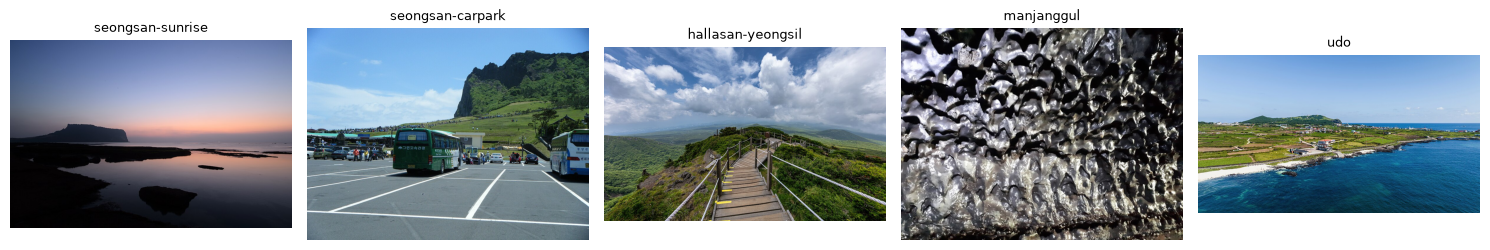

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (name, (_url, title)) in zip(axes, IMAGES.items()):
    img = Image.open(f"week06-imgs/{name}.jpg").convert("RGB")
    ax.imshow(img)
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 1-3. CLIP 제로샷 - 사진과 문장의 유사도

CLIP은 이미지 인코더와 텍스트 인코더 **둘**을 가진다. 이미지 인코더는 ViT-B/32다. 사진을 224x224로 맞춘 뒤 32x32 픽셀 조각(패치) 7x7=49개로 잘라 조각 하나를 토큰처럼 읽는다. 두 인코더가 각자 벡터를 만들고, 벡터를 길이 1로 정규화한 뒤 내적하면 코사인 유사도가 나온다.

사진 5장 x 후보 문장 5개의 유사도 행렬을 만들어 본다. 각 행에서 가장 큰 값이 모델이 고른 문장이다.

In [4]:
import torch
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").eval()
clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print(f"logit_scale: {clip.logit_scale.exp().item():.1f}")

def clip_similarity(image_paths, texts):
    # 이미지와 문장을 각자 인코딩해 정규화한 뒤 내적한다
    imgs = [Image.open(p).convert("RGB") for p in image_paths]
    with torch.no_grad():
        img_inputs = clip_proc(images=imgs, return_tensors="pt")
        img_emb = clip.get_image_features(pixel_values=img_inputs["pixel_values"])
        if hasattr(img_emb, "pooler_output"):
            img_emb = img_emb.pooler_output
        txt_inputs = clip_proc(text=texts, return_tensors="pt", padding=True)
        txt_emb = clip.get_text_features(
            input_ids=txt_inputs["input_ids"], attention_mask=txt_inputs["attention_mask"]
        )
        if hasattr(txt_emb, "pooler_output"):
            txt_emb = txt_emb.pooler_output
        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
        txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)
        return (img_emb @ txt_emb.T).tolist()

# 동작 확인: 첫 사진 1장, 짧은 영어 라벨 5개
labels_en_coarse = [
    "a photo of a sunrise peak",
    "a photo of a parking lot",
    "a photo of a hiking trail",
    "a photo of a lava tube cave",
    "a photo of a coastal island",
]
paths = [f"week06-imgs/{name}.jpg" for name in IMAGES]
sim = clip_similarity(paths, labels_en_coarse)
print(f"\n{IMAGES['seongsan-sunrise'][1]} 행:")
for lab, v in zip(labels_en_coarse, sim[0]):
    print(f"  {v:+.3f}  {lab}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

logit_scale: 100.0



Sunrise with Seongsan Ilchulbong 행:
  +0.266  a photo of a sunrise peak
  +0.222  a photo of a parking lot
  +0.226  a photo of a hiking trail
  +0.184  a photo of a lava tube cave
  +0.274  a photo of a coastal island


### 1-4. 라벨 언어가 결과를 바꾼다 - 유사도 히트맵

같은 사진 5장에 라벨 조합을 네 가지로 바꿔가며 제로샷 분류를 돌린다.

- **영어 (짧은)**: `a photo of a ...` 뒤에 짧은 영어 라벨
- **영어 (장면 묘사)**: 장면을 묘사하는 긴 영어 라벨
- **한국어**: `... 사진` 형식의 한국어 라벨
- **한국어 + 영어 섞기**: 한국어 라벨에 영어를 괄호로 붙임

라벨 조합마다 **각 사진이 고른 라벨**도 출력한다. 한국어 라벨에서 여러 사진이 같은 라벨로 쏠리는지 보자.

히트맵에서 행: 사진, 열: 후보 라벨이다. 가장 진한 칸이 모델이 고른 라벨이고, **대각선이 진하면 정답을 골라낸 것**이다.

en_coarse: 대각선 정답 4/5
    seongsan-sunrise   -> a photo of a coastal island  (오답)
    seongsan-carpark   -> a photo of a parking lot
    hallasan-yeongsil  -> a photo of a hiking trail
    manjanggul         -> a photo of a lava tube cave
    udo                -> a photo of a coastal island


en_scenario: 대각선 정답 5/5
    seongsan-sunrise   -> a photo of a sunrise over a volcanic crater by the sea
    seongsan-carpark   -> a photo of a parking lot full of tour buses
    hallasan-yeongsil  -> a photo of a wooden staircase on a forest hiking trail
    manjanggul         -> a photo of a dark lava tube cave interior
    udo                -> a photo of green sea cliffs and a small island


ko: 대각선 정답 1/5
    seongsan-sunrise   -> 성산일출봉 사진
    seongsan-carpark   -> 성산일출봉 사진  (오답)
    hallasan-yeongsil  -> 성산일출봉 사진  (오답)
    manjanggul         -> 성산일출봉 사진  (오답)
    udo                -> 주차장 사진  (오답)


ko_english_mix: 대각선 정답 4/5
    seongsan-sunrise   -> 해안 섬 (coastal island) photo  (오답)
    seongsan-carpark   -> 주차장 (parking lot) photo
    hallasan-yeongsil  -> 등산로 (hiking trail) photo
    manjanggul         -> 용암동굴 (lava tube cave) photo
    udo                -> 해안 섬 (coastal island) photo


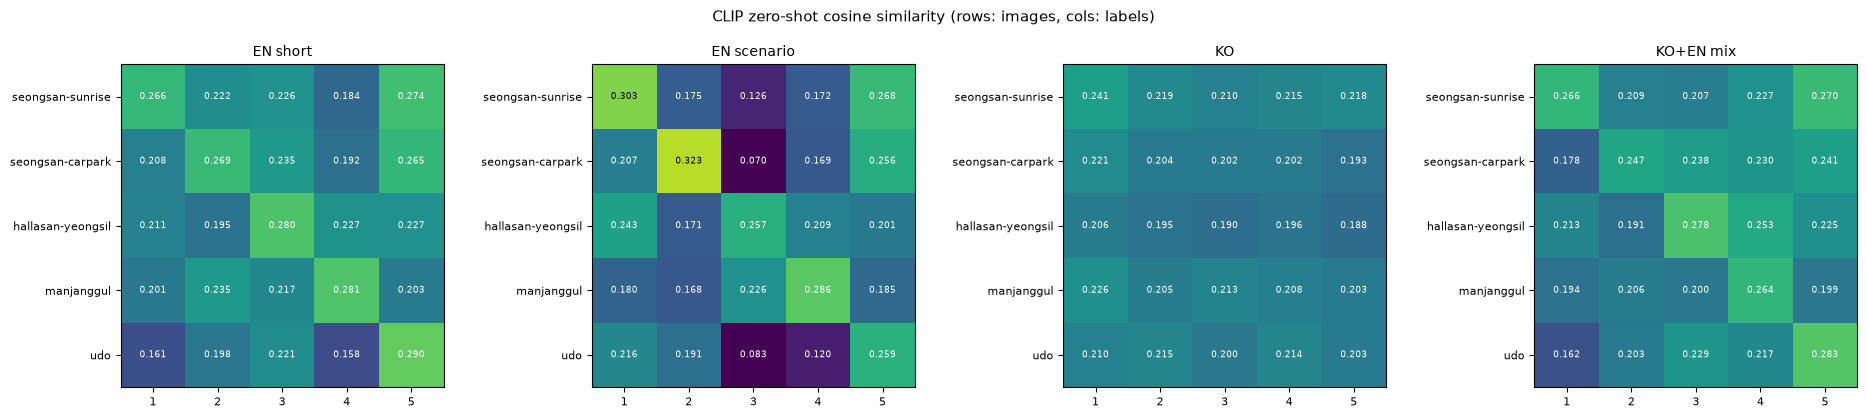

열 라벨 번호:
  en_coarse: 1=a photo of a sunrise peak, 2=a photo of a parking lot, 3=a photo of a hiking trail, 4=a photo of a lava tube cave, 5=a photo of a coastal island
  en_scenario: 1=a photo of a sunrise over a volcanic crater by the sea, 2=a photo of a parking lot full of tour buses, 3=a photo of a wooden staircase on a forest hiking trail, 4=a photo of a dark lava tube cave interior, 5=a photo of green sea cliffs and a small island
  ko: 1=성산일출봉 사진, 2=주차장 사진, 3=등산로 사진, 4=용암동굴 사진, 5=해안 섬 사진
  ko_english_mix: 1=성산일출봉 (Seongsan Ilchulbong) sunrise peak photo, 2=주차장 (parking lot) photo, 3=등산로 (hiking trail) photo, 4=용암동굴 (lava tube cave) photo, 5=해안 섬 (coastal island) photo


In [5]:
LABEL_SETS = {
    "en_coarse": labels_en_coarse,
    "en_scenario": [
        "a photo of a sunrise over a volcanic crater by the sea",
        "a photo of a parking lot full of tour buses",
        "a photo of a wooden staircase on a forest hiking trail",
        "a photo of a dark lava tube cave interior",
        "a photo of green sea cliffs and a small island",
    ],
    "ko": [
        "성산일출봉 사진",
        "주차장 사진",
        "등산로 사진",
        "용암동굴 사진",
        "해안 섬 사진",
    ],
    "ko_english_mix": [
        "성산일출봉 (Seongsan Ilchulbong) sunrise peak photo",
        "주차장 (parking lot) photo",
        "등산로 (hiking trail) photo",
        "용암동굴 (lava tube cave) photo",
        "해안 섬 (coastal island) photo",
    ],
}

img_names = list(IMAGES)
all_sims = {}
for set_name, labels in LABEL_SETS.items():
    all_sims[set_name] = clip_similarity(paths, labels)
    correct = sum(1 for i in range(len(paths)) if max(range(len(labels)), key=lambda j: all_sims[set_name][i][j]) == i)
    print(f"{set_name}: 대각선 정답 {correct}/{len(paths)}")
    for i, name in enumerate(img_names):
        j = max(range(len(labels)), key=lambda j: all_sims[set_name][i][j])
        print(f"    {name:<18} -> {labels[j]}{'' if j == i else '  (오답)'}")

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
short = {"en_coarse": "EN short", "en_scenario": "EN scenario", "ko": "KO", "ko_english_mix": "KO+EN mix"}
for ax, (set_name, labels) in zip(axes, LABEL_SETS.items()):
    data = all_sims[set_name]
    ax.imshow(data, cmap="viridis", vmin=0.1, vmax=0.35)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(range(1, len(labels) + 1), fontsize=8)
    ax.set_yticks(range(len(img_names)))
    ax.set_yticklabels(img_names, fontsize=8)
    for i in range(len(paths)):
        for j in range(len(labels)):
            ax.text(j, i, f"{data[i][j]:.3f}", ha="center", va="center", fontsize=6.5,
                    color="white" if data[i][j] < 0.3 else "black")
    ax.set_title(short[set_name], fontsize=10)
plt.suptitle("CLIP zero-shot cosine similarity (rows: images, cols: labels)", fontsize=11)
plt.tight_layout()
plt.show()

print("열 라벨 번호:")
for set_name, labels in LABEL_SETS.items():
    print(f"  {set_name}: " + ", ".join(f"{j+1}={l}" for j, l in enumerate(labels)))

### 1-5. 한국어 라벨은 토큰에서 어떻게 되는가

한국어 라벨이 무너지는 원인을 토큰에서 확인한다. CLIP의 토크나이저는 한국어 글자를 **바이트 조각**으로 자른다. 한글 한 글자는 UTF-8로 3바이트라서 보통 1~2개 조각이 된다. CLIP의 텍스트 인코더는 한 문장에 토큰을 77개까지만 받으므로, 한국어는 같은 길이의 영어보다 이 한도에 빨리 닿는다. 토큰 자체는 만들어지므로 무너지는 원인은 토큰화가 아니라, 그 토큰들이 사진 내용과 짝지어져 학습된 일이 드물다는 것(학습 데이터가 영어 위주)이다. 그래서 다섯 한국어 라벨의 벡터가 서로 거의 구별되지 않는다.

In [6]:
ko_text = "성산일출봉 사진"
ko_inputs = clip_proc(text=[ko_text], return_tensors="pt")
ko_ids = ko_inputs["input_ids"][0].tolist()
en_text = "a photo of a sunrise peak"
en_inputs = clip_proc(text=[en_text], return_tensors="pt")
en_ids = en_inputs["input_ids"][0].tolist()

print(f"한국어 '{ko_text}' -> 토큰 {len(ko_ids)}개: {ko_ids}")
print(f"영어   '{en_text}' -> 토큰 {len(en_ids)}개: {en_ids}")
print(f"'성' 한 글자 -> 조각 {len(clip_proc.tokenizer('성', add_special_tokens=False).input_ids)}개: {clip_proc.tokenizer.tokenize('성')}")
print(f"어휘 크기: {clip.config.text_config.vocab_size} (바이트 단위 BPE 어휘 전체)")
print()
print("한국어는 글자가 바이트 조각으로 분해된다. 토큰은 만들어지지만,")
print("그 토큰들이 사진 내용과 짝지어져 학습된 일이 드물어 라벨끼리 벡터가 거의 구별되지 않는다.")

한국어 '성산일출봉 사진' -> 토큰 14개: [49406, 15074, 109, 31061, 108, 43406, 42476, 39810, 112, 487, 31061, 105, 38890, 49407]
영어   'a photo of a sunrise peak' -> 토큰 8개: [49406, 320, 1125, 539, 320, 5610, 6026, 49407]
'성' 한 글자 -> 조각 2개: ['ìĦ', '±</w>']
어휘 크기: 49408 (바이트 단위 BPE 어휘 전체)

한국어는 글자가 바이트 조각으로 분해된다. 토큰은 만들어지지만,
그 토큰들이 사진 내용과 짝지어져 학습된 일이 드물어 라벨끼리 벡터가 거의 구별되지 않는다.


### 1-6. SmolVLM 질의응답 - 사진을 언어모형에 넣기

이제 생성형이다. SmolVLM-256M-Instruct는 사진을 **시각 토큰**으로 바꿔 언어모형의 문맥에 끼워 넣는다.

시각 토큰 수는 **타일 분할** 설정이 크게 바꾼다.

- 분할을 켜면(모델 기본값) 사진을 긴 변 2048로 키운 뒤 512x512 타일로 자르고, 전체 사진 축소본 1장을 더한다. 타일 1장이 64토큰이므로 960x640 사진은 타일 12장 + 1장 = 13장 x 64 = **832토큰**이다
- 분할을 끄면 전체 사진 1장만 넣어 **64토큰**이다

분할을 켜면 CPU에서 답 하나에 수십 초가 걸린다. 그래서 이 노트북은 **분할을 끄고(`SPLIT = False`) 답을 생성한다.** 분할을 켰을 때와의 차이는 1-10에서 직접 잰다.

절차는 세 단계다.

1. 채팅 템플릿으로 대화 형식 프롬프트를 조립한다 (이미지 자리는 표시자로 둔다)
2. 사진과 프롬프트를 프로세서에 넣어 모델 입력을 만든다
3. `generate()`로 답을 생성한다

In [7]:
from transformers import AutoProcessor, AutoModelForImageTextToText

vlm_name = "HuggingFaceTB/SmolVLM-256M-Instruct"
vlm_processor = AutoProcessor.from_pretrained(vlm_name)
vlm = AutoModelForImageTextToText.from_pretrained(vlm_name).eval()

SPLIT = False  # 타일 분할. False면 사진 1장이 시각 토큰 64개가 되어 CPU에서도 빠르게 답한다
vlm_processor.image_processor.do_image_splitting = SPLIT

total_params = sum(p.numel() for p in vlm.parameters())
print(f"전체 파라미터: {total_params:,}")

def build_inputs(img, question, split=None):
    # 채팅 템플릿으로 프롬프트를 만들고 사진과 함께 모델 입력으로 바꾼다
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]}]
    prompt = vlm_processor.apply_chat_template(messages, add_generation_prompt=True)
    kw = {} if split is None else {"do_image_splitting": split}
    return vlm_processor(images=img, text=prompt, return_tensors="pt", **kw)

def vlm_ask(image_path, question, max_new_tokens=48):
    # 사진과 질문을 넣어 답을 생성한다 (탐욕 디코딩이라 매번 같은 답)
    img = Image.open(image_path).convert("RGB")
    inputs = build_inputs(img, question)
    with torch.no_grad():
        out = vlm.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    text = vlm_processor.batch_decode(out, skip_special_tokens=True)[0]
    return text.split("Assistant:")[-1].strip()

def visual_token_count(img, split):
    # 입력 전체 토큰 수와 그중 시각 토큰(이미지 표시자) 수를 센다
    ids = build_inputs(img, "Describe this image.", split=split)["input_ids"][0].tolist()
    return len(ids), sum(1 for t in ids if t == vlm_processor.image_token_id)

first = "week06-imgs/seongsan-sunrise.jpg"
img0 = Image.open(first).convert("RGB")
for split in [True, False]:
    n_total, n_vis = visual_token_count(img0, split)
    print(f"분할 {'켬' if split else '끔'}: 입력 토큰 {n_total}개 중 시각 토큰 {n_vis}개 ({n_vis / n_total:.0%})")

print("\n동작 확인:")
q = "Describe this image in one sentence."
print(f"Q: {q}")
print(f"A: {vlm_ask(first, q)}")

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

전체 파라미터: 256,484,928
분할 켬: 입력 토큰 874개 중 시각 토큰 832개 (95%)
분할 끔: 입력 토큰 79개 중 시각 토큰 64개 (81%)

동작 확인:
Q: Describe this image in one sentence.


A: In this image we can see a hill. At the bottom of the image there is water. At the top of the image there is sky.


### 1-7. 사진만 바꿔 보기 - 답이 사진을 따라 움직이는가

질문을 고정하고 **사진만** 다섯 장으로 바꿔 본다. 답이 사진 내용을 따라 바뀌면 답이 이미지에 근거(grounded) 있다는 뜻이다.

In [8]:
QUESTION_EN = "Describe this image in one sentence."
print(f"질문(고정): {QUESTION_EN}\n")
for name in IMAGES:
    path = f"week06-imgs/{name}.jpg"
    answer = vlm_ask(path, QUESTION_EN)
    print(f"[{name}]")
    print(f"  {answer}\n")

질문(고정): Describe this image in one sentence.



[seongsan-sunrise]
  In this image we can see a hill. At the bottom of the image there is water. At the top of the image there is sky.



[seongsan-carpark]
  In this image we can see a few vehicles on the road. In the background there is a mountain and the sky is clear.



[hallasan-yeongsil]
  In this image we can see a bridge, trees, mountains and the sky.



[manjanggul]
  In this image we can see a black color object.



[udo]
  In this image we can see a group of people, there are some trees, there is a water body, there is a hill, there is a clear sky, there are some clouds in the sky.



### 1-8. 한국어 질문은 어떻게 깨지는가

같은 사진들에 한국어 질문을 넣어 본다. 답이 영어로 나오거나, 질문과 상관없는 내용이 나오거나, 깨진 한글이 나온다. 영어 질문일 때보다 답이 사진에서 멀어지는 경우도 찾아보자.

원인은 모델 크기만이 아니라 **학습 데이터의 언어 분포**다. 256M 모델의 지시 학습 데이터는 영어 위주라 한국어 지시 뒤의 다음 토큰 확률이 무너진다.

In [9]:
QUESTION_KO = "이 이미지를 한 문장으로 묘사하라."
print(f"Q: {QUESTION_KO}\n")
for name in IMAGES:
    print(f"[{name}] {vlm_ask(f'week06-imgs/{name}.jpg', QUESTION_KO)}")

q2 = "여기가 어디인가? 주된 피사체가 무엇인가?"
print(f"\nQ: {q2}")
print(f"[seongsan-sunrise] {vlm_ask(first, q2)}")

Q: 이 이미지를 한 문장으로 묘사하라.



[seongsan-sunrise] The sunset over a body of water.


[seongsan-carpark] The 2019-2020 season.


[hallasan-yeongsil] The path is very wide and is made of wooden planks.


[manjanggul] The top of a car door.


[udo] The water is a beautiful blue.

Q: 여기가 어디인가? 주된 피사체가 무엇인가?


[seongsan-sunrise] 어디에서 이미지를 이벤트로보기를 해


### 1-9. 텍스트 전용 모델에게 같은 질문을 하면

온라인 학습활동의 비교다. 사진을 받을 수 없는 텍스트 전용 모델(Qwen3-0.6B-Base, 4·5주차와 같은 모델)에게 같은 질문을 준다. 사진이 없으니 모델은 **문맥만 보고 그럴듯한 장면을 지어낸다.** 답이 사진과 아무 관계가 없다는 것을 확인하자.

프롬프트 형식은 `Question: ...\nAnswer:`이고 탐욕 디코딩이라 매번 같은 답이 나온다.

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM

txt_name = "Qwen/Qwen3-0.6B-Base"
txt_tok = AutoTokenizer.from_pretrained(txt_name)
txt_model = AutoModelForCausalLM.from_pretrained(txt_name).eval()

def text_only_ask(question, max_new_tokens=40):
    ids = txt_tok(f"Question: {question}\nAnswer:", return_tensors="pt").input_ids
    with torch.no_grad():
        out = txt_model.generate(ids, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=txt_tok.eos_token_id)
    return txt_tok.decode(out[0][ids.shape[1]:], skip_special_tokens=True).strip()

for q in ["Describe this image in one sentence.", "What is in this photo?", "사진 속에 나무가 몇 그루인가?"]:
    print(f"Q: {q}")
    print(f"  텍스트 전용: {text_only_ask(q)}")
    print(f"  SmolVLM (성산 사진): {vlm_ask(first, q)}\n")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Q: Describe this image in one sentence.


  텍스트 전용: The image depicts a serene landscape with lush greenery, a tranquil river, and a group of people engaged in a peaceful activity, likely fishing or enjoying the surroundings.


  SmolVLM (성산 사진): In this image we can see a hill. At the bottom of the image there is water. At the top of the image there is sky.

Q: What is in this photo?


  텍스트 전용: The answer is a man in a white shirt and a man in a black shirt. The man in the white shirt is a man who is playing a guitar. The man in the black shirt is a


  SmolVLM (성산 사진): A seascape featuring a hill on the horizon.

Q: 사진 속에 나무가 몇 그루인가?


  텍스트 전용: 사진 속에 나무가 몇 그루인가에 대한 답은 상황에 따라 달라질 수 있습니다. 일반적으로 나무의 수는 100~


  SmolVLM (성산 사진): Yes, it is a beautiful sunset. The sky looks very dark, but the sun is still rising, and the water is still. The water looks calm and still, and there are no waves or ripples. The sky looks dark, but



### 1-10. 시각 토큰 수는 무엇이 정하나 - 크기, 비율, 분할

학습활동 [실무]의 지연·비용 보고를 위한 측정이다. 같은 사진을 여러 크기와 가로세로 비율로 바꿔 시각 토큰 수를 센다. **해상도를 올리면 토큰이 늘어날까?** 먼저 예상해 보고 실행하자.

마지막 줄은 분할을 켰을 때와 껐을 때 **첫 토큰이 나오기까지 걸린 시간**이다. 사진을 읽고 문맥을 처리하는 비용이 이 시간에 들어 있다. Colab 무료 CPU에서는 이보다 오래 걸릴 수 있다.

In [11]:
import time

# 한글은 고정폭 글꼴에서 두 칸을 차지하므로 머리글은 그만큼 적게 채운다
print(f"{'크기':<10} {'분할 켬':>5} {'분할 끔':>5}")
for w, h in [(240, 160), (960, 640), (1920, 1280), (640, 640), (1280, 320)]:
    im = img0.resize((w, h))
    on, off = visual_token_count(im, True)[1], visual_token_count(im, False)[1]
    size = f"{w}x{h}"
    print(f"{size:<12} {on:>8} {off:>8}")

for split in [True, False]:
    inputs = build_inputs(img0, "Describe this image in one sentence.", split=split)
    t = time.time()
    with torch.no_grad():
        vlm.generate(**inputs, max_new_tokens=1, do_sample=False)
    print(f"분할 {'켬' if split else '끔'}: 입력 {inputs['input_ids'].shape[1]}토큰, 첫 토큰까지 {time.time() - t:.1f}초")

크기          분할 켬  분할 끔
240x160           832       64
960x640           832       64
1920x1280         832       64


640x640          1088       64
1280x320          320       64


분할 켬: 입력 877토큰, 첫 토큰까지 96.9초


분할 끔: 입력 82토큰, 첫 토큰까지 5.7초


## 2. 한 지점만 바꿔 보기 - 입력 이미지를 바꾼다

아래 셀의 `# TODO`로 표시된 **한 곳만** 바꾸고 다시 실행하세요.

> 규칙: `MY_IMAGE`를 다른 사진 이름으로 바꾼다. 후보는 `seongsan-sunrise`, `seongsan-carpark`, `hallasan-yeongsil`, `manjanggul`, `udo` 다섯 가지다. 바꾼 뒤 두 가지를 기록한다. (1) 같은 질문인데 답이 사진을 따라 바뀌는가. (2) 바꾼 사진의 특징이 답에 어떻게 반영되는가(또는 어두운 사진에서 답이 어떻게 무너지는가). 이것이 학습활동 [구현]의 기록이다.

> 과제 2: 이 셀이 과제 2의 골격이다. 체크리스트 2단계에서 고른 공개 사진을 jpg, png, webp 파일로 왼쪽 파일 창의 `week06-imgs/` 폴더에 올리고 `MY_IMAGE`를 그 파일 이름(확장자 제외)으로 바꾼다. 셀 끝의 [비용] 줄이 보고 표에 옮길 숫자다. 단계는 강의 노트 6주차의 과제 2 따라 하기 체크리스트에 있다.

In [12]:
# TODO: 사진 이름을 바꾼다. 후보: seongsan-sunrise / seongsan-carpark / hallasan-yeongsil / manjanggul / udo
# (과제 2) week06-imgs/ 폴더에 올린 공개 사진(jpg, png, webp)이면 그 파일 이름을 확장자 없이 쓴다
# TODO 적용 (과제 2): 관측 장비 사진 - NOAA PMEL "Papa 2009 recovery" (위키미디어 공용, Public domain), 960x1280으로 받아 올림
MY_IMAGE = "papa-buoy"

# 아래는 그대로 둡니다
import glob
found = sorted(p for p in glob.glob(f"week06-imgs/{MY_IMAGE}.*") if p.lower().endswith((".jpg", ".jpeg", ".png", ".webp")))
assert found, f"week06-imgs/ 폴더에 {MY_IMAGE}.jpg (또는 .jpeg, .png, .webp) 사진이 없다. 파일 이름을 확인하고, svg나 pdf는 png로 바꿔 올리자"
path = found[0]
print(f"사진: {path}")
print(f"\n[영어 질문]")
q = "Describe this image in one sentence."
a = vlm_ask(path, q)
print(f"  Q: {q}")
print(f"  A: {a}")
print(f"\n[한국어 질문]")
q_ko = "이 이미지를 한 문장으로 묘사하라."
a_ko = vlm_ask(path, q_ko)
print(f"  Q: {q_ko}")
print(f"  A: {a_ko}")
print(f"\n[제로샷 - 이 사진은 다섯 라벨 중 어디에 가까운가]")
sim_one = clip_similarity([path], LABEL_SETS["en_coarse"])[0]
best = max(range(5), key=lambda j: sim_one[j])
for j, (lab, v) in enumerate(zip(LABEL_SETS["en_coarse"], sim_one)):
    mark = "  <-- 모델의 선택" if j == best else ""
    print(f"  {v:+.3f}  {lab}{mark}")

print(f"\n[비용 - 이 사진을 붙이면 무엇이 늘어나나] (과제 2 보고용)")
img = Image.open(path).convert("RGB")
ctx = vlm.config.text_config.max_position_embeddings
print(f"  사진 크기 {img.width}x{img.height}, 문맥 창 {ctx:,}토큰")

def first_token_time(inputs):
    t = time.time()
    with torch.no_grad():
        vlm.generate(**inputs, max_new_tokens=1, do_sample=False)
    return f"{time.time() - t:.2f}초"

question_only = vlm_processor(
    text=vlm_processor.apply_chat_template([{"role": "user", "content": [{"type": "text", "text": q}]}], add_generation_prompt=True),
    return_tensors="pt",
)
rows = [
    ("질문만 (사진 없음)", question_only, True),
    ("사진 + 질문 (분할 끔)", build_inputs(img, q, split=False), True),
    ("사진 + 질문 (분할 켬)", build_inputs(img, q, split=True), False),  # CPU에서 수십 초라 재지 않는다
]
for label, inputs, timed in rows:
    ids = inputs["input_ids"][0].tolist()
    n_vis = sum(1 for t in ids if t == vlm_processor.image_token_id)
    secs = first_token_time(inputs) if timed else "1-10의 값을 쓴다"
    print(f"  {label}: 입력 {len(ids)}토큰, 시각 토큰 {n_vis}개 (문맥 창의 {n_vis / ctx:.1%}), 첫 토큰까지 {secs}")

사진: week06-imgs/papa-buoy.jpg

[영어 질문]


  Q: Describe this image in one sentence.
  A: In this image we can see a ship on the water.

[한국어 질문]


  Q: 이 이미지를 한 문장으로 묘사하라.
  A: Papa Climate.

[제로샷 - 이 사진은 다섯 라벨 중 어디에 가까운가]


  +0.196  a photo of a sunrise peak
  +0.179  a photo of a parking lot
  +0.164  a photo of a hiking trail
  +0.151  a photo of a lava tube cave
  +0.218  a photo of a coastal island  <-- 모델의 선택

[비용 - 이 사진을 붙이면 무엇이 늘어나나] (과제 2 보고용)
  사진 크기 960x1280, 문맥 창 8,192토큰
  질문만 (사진 없음): 입력 15토큰, 시각 토큰 0개 (문맥 창의 0.0%), 첫 토큰까지 0.05초


  사진 + 질문 (분할 끔): 입력 82토큰, 시각 토큰 64개 (문맥 창의 0.8%), 첫 토큰까지 5.63초
  사진 + 질문 (분할 켬): 입력 878토큰, 시각 토큰 832개 (문맥 창의 10.2%), 첫 토큰까지 1-10의 값을 쓴다


## 3. 정리 그래프

네 라벨 조합의 대각선 정답 수를 막대로 그린다. 라벨 언어가 제로샷을 어떻게 바꾸는지 한눈에 본다.

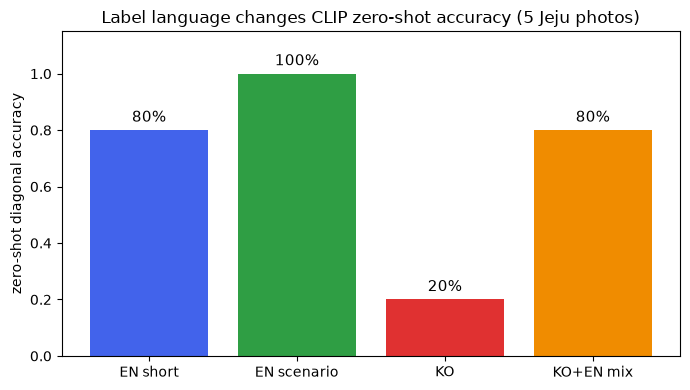

In [13]:
accs = {}
for set_name, labels in LABEL_SETS.items():
    accs[set_name] = sum(
        1 for i in range(len(paths)) if max(range(len(labels)), key=lambda j: all_sims[set_name][i][j]) == i
    ) / len(paths)

plt.figure(figsize=(7, 4))
names = [short[n] for n in LABEL_SETS]
vals = [accs[n] for n in LABEL_SETS]
bars = plt.bar(names, vals, color=["#4263eb", "#2f9e44", "#e03131", "#f08c00"])
for bar, v in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.03, f"{v:.0%}", ha="center", fontsize=11)
plt.ylim(0, 1.15)
plt.ylabel("zero-shot diagonal accuracy")
plt.title("Label language changes CLIP zero-shot accuracy (5 Jeju photos)")
plt.tight_layout()
plt.show()

## 4. 확인 질문

1. 라벨 조합 네 가지의 대각선 정답 수는 각각 몇이었나요? 한국어 라벨에서 사진들은 어느 라벨로 쏠렸나요?
2. 영어 짧은 라벨에서 틀린 사진은 무엇이고, 두 후보의 유사도 차이는 얼마였나요? logit_scale 100을 곱하면 확률은 어떻게 갈리나요?
3. 1-7에서 사진을 바꿨을 때 답이 사진을 따라 바뀌었나요? 답에 사진에 없는 것이 들어간 경우가 있었나요?
4. 1-9에서 텍스트 전용 모델의 답은 사진과 어떤 관계였나요? 5주차의 어떤 개념과 이어지나요?
5. 1-10에서 해상도를 올리면 시각 토큰이 늘었나요? 토큰 수를 실제로 바꾼 것은 무엇이었나요?
6. 한국어 질문의 답은 어떤 모양이었나요? 질문 언어와 답 언어의 관계에서 관찰한 것을 한 문장으로 써 보세요.

답은 아래 셀에 글로 적으면 됩니다. 코드가 아니어도 됩니다.

**답**

> 측정 환경: Colab이 아니라 Apple M1 맥북 CPU에서 실행했다(GPU 없음). 시간 값은 이 환경 기준이다.

1. 대각선 정답 수는 영어 짧은 라벨 4/5, 영어 장면 묘사 5/5, 한국어 1/5, 한국어+영어 섞기 4/5다. 한국어 라벨에서는 사진 4장(성산 일출, 성산 주차장, 영실 등산로, 만장굴)이 모두 "성산일출봉 사진"으로 쏠렸고, 우도는 "주차장 사진"을 골랐다. 1/5는 한 장을 알아본 것이 아니라, 거의 모든 사진이 첫 라벨을 고르는 상태에서 첫 사진이 우연히 그 라벨의 정답이었을 뿐이다.
2. 영어 짧은 라벨에서 틀린 사진은 성산 일출(seongsan-sunrise)이다. sunrise peak 0.266, coastal island 0.274로 차이가 0.008뿐인데 coastal island를 골랐다. logit_scale 100을 곱하면 로짓이 26.6과 27.4로 차이 0.8이 되고, 확률 비는 e^0.8 ≈ 2.2배다. 다섯 라벨 softmax로 계산하면 sunrise peak 0.307, coastal island 0.683으로 갈린다. 코사인의 근소한 차이가 확률에서는 크게 벌어진다.
3. 바뀌었다. 같은 질문에 성산 일출은 언덕·물·하늘, 주차장은 도로 위 차량과 산, 영실은 다리·나무·산, 만장굴은 "검은색 물체", 우도는 물·언덕·하늘로 답해 사진을 따라 움직였다. 사진에 없는 것도 들어갔다. 우도 사진은 위에서 찍은 해안 풍경으로 사람이 보이지 않는데 "a group of people"이 나왔고, 영실의 나무 계단은 "bridge"로 답했다. 어두운 만장굴에서는 답이 "a black color object"로 무너졌다.
4. 텍스트 전용 모델의 답은 사진과 아무 관계가 없었다. 사진을 본 적이 없으니 "강과 낚시하는 사람들", "흰 셔츠를 입고 기타 치는 남자"처럼 언어적으로 그럴듯한 장면을 지어냈다. 5주차의 false acceptance와 같은 뿌리다. 다음 토큰 확률이 높다는 것은 그럴듯하다는 뜻이지 참이라는 뜻이 아니다.
5. 늘지 않았다. 분할을 켰을 때 240x160, 960x640, 1920x1280이 모두 832토큰이었다. 토큰 수를 실제로 바꾼 것은 **비율**과 **분할 설정**이다. 정사각형 640x640은 1,088토큰, 납작한 1280x320은 320토큰이고, 분할을 끄면 크기·비율과 상관없이 모두 64토큰이었다. 사진을 긴 변 2048로 맞춘 뒤 512 타일로 자르기 때문에 해상도가 아니라 비율이 타일 수를 정한다.
6. 한국어로 물어도 답은 대부분 영어였고("The sunset over a body of water.", "The water is a beautiful blue."), 사진에서 먼 답("The 2019-2020 season.", 만장굴에 "The top of a car door.")과 깨진 한글("어디에서 이미지를 이벤트로보기를 해")도 나왔다. 질문 언어가 한국어로 바뀌면 답 언어는 따라오지 않고 영어로 돌아가며, 영어 질문보다 사진에서 더 멀어진다.

**학습활동 [구현] - TODO에서 사진 바꾸기 (관측 장비 사진)**

- 영어 질문: "In this image we can see a ship on the water." 물은 맞지만 부이를 배로 봤다.
- 한국어 질문: "Papa Climate." 사진을 묘사하지 않고 부이에 적힌 글자 "PAPA - CLIMATE"를 읽어 그대로 내놓았다. 질문은 한국어인데 답은 영어 글자다.
- CLIP 제로샷: 다섯 라벨(제주 장소용) 중 맞는 것이 없는데도 coastal island(0.218)를 골랐다. 제로샷은 후보에 정답이 없어도 하나를 고른다.

**과제 2 - QA 골격에 관측 장비 사진 연결**

- **상정한 조건**: 도내 해양·환경 관측 기록을 다루는 기업. 관측 사진을 받는 CPU 서버 1대, 전용 GPU 없음, 사진 1장당 첫 응답 5초 이내. (조건 상정이며 기업 데이터는 쓰지 않았다)
- **모달리티**: 관측 장비 사진
- **사용한 공개 사진**: "Papa 2009 recovery" (Ocean station P instrumentation buoy, as it appeared in 2009). 저자 Pacific Marine Environmental Laboratory (NOAA PMEL). 출처 https://commons.wikimedia.org/wiki/File:Papa_2009_recovery.jpg . 라이선스 Public domain. 위키미디어 공용의 960px 축소본(960x1280)을 `week06-imgs/papa-buoy.jpg`로 올렸다. 사람이나 개인정보는 나오지 않는다.

| 입력 | 입력 토큰 | 시각 토큰 | 문맥 창(8,192) 대비 시각 토큰 | 첫 토큰까지 |
|---|---|---|---|---|
| 질문만 (사진 없음) | 15 | 0 | 0% | 0.05초 |
| 사진 + 질문 (분할 끔) | 82 | 64 | 0.8% | 5.63초 |
| 사진 + 질문 (분할 켬) | 878 | 832 | 10.2% | 96.9초 (1-10 참고값) |

- 1-10의 참고값은 960x640 사진(입력 877토큰)에서 쟀다. 부이 사진은 세로 3:4라 비율은 다르지만, 긴 변 2048로 맞추면 1536x2048이 되어 512 타일 3x4 = 12장에 전체 1장을 더한 13장 x 64 = 832토큰으로 같다. 입력 토큰은 878로 1개 차이다.
- **잠식 지점**: 분할을 켜면 사진 1장이 문맥 창의 10.2%를 쓴다. 9장이면 시각 토큰만 7,488개(91%)이고, 10장이면 8,320개로 문맥 창 8,192를 넘는다. 분할을 끄면 1장이 0.8%라 시각 토큰만으로 128장에서 꽉 차고, 질문 토큰까지 더하면 127장 정도다.
- **선택**: 분할 끔. 첫 응답이 5.63초로 분할 켬(96.9초)의 약 17분의 1이고, 문맥 창도 한 장에 0.8%만 쓴다. 분할 켬은 조건 5초를 19배 넘어 후보가 될 수 없다.

관찰: 부이 사진에 질문하면 분할을 꺼도 첫 토큰까지 5.63초가 걸려 조건(5초)을 0.63초 넘는다. 분할을 켜면 96.9초이고 시각 토큰이 832개로 문맥 창의 10.2%를 차지한다.
근거: SmolVLM-256M-Instruct, 공개 사진 "Papa 2009 recovery"(960x1280), 노트북 2절 [비용] 출력과 1-10 실측. 사진 없이 질문만 넣으면 첫 토큰까지 0.05초다.
해석: 질문만일 때 0.05초이므로 첫 응답 시간의 대부분은 사진을 읽는 비용(비전 인코더와 시각 토큰 처리)이다. 해상도를 바꿔도 토큰이 줄지 않으니, 비용을 정하는 손잡이는 분할 설정과 사진 비율이다. 분할을 끄면 토큰과 시간이 함께 줄어 조건에 가장 가깝다.
다음: 분할 끔을 채택한다. 이번 수치는 M1 맥북 CPU 기준이라, 상정한 CPU 서버에서 같은 사진으로 첫 응답 시간을 다시 잰다. 그래도 5초를 넘으면 조건을 6초 이내로 조정하자고 제안한다.


## 5. 제출

1. 상단 메뉴 **파일 > .ipynb 다운로드** 로 이 노트북을 내려받습니다
2. [저장소](https://github.com/halla-ai/deepnlp-2026)의 `assignments/week-06/<내 학번>/` 에 업로드합니다
3. Pull Request를 엽니다

자세한 방법은 강의 사이트의 **과제 제출** 문서에 있습니다.

---

**막혔나요?** 오류 메시지의 마지막 줄을 먼저 읽어 보세요. 그래도 안 되면 AI Professor 튜터에게 묻고, 그래도 막히면 저장소 Issues에 남기세요.